In [7]:
import pandas as pd

In [8]:
df = pd.read_csv("to_ML.csv")

In [9]:
df.columns

Index(['シーズン', '大会', '節', '試合日', 'K/O時刻', 'ホーム', 'スコア', 'アウェイ', 'スタジアム',
       '入場者数', 'インターネット中継・TV放送', 'コロナ禍ダミー', '国立フラグ', '曜日', '休日フラグ',
       'rolling_mean_3', 'datetime', 'date', 'year', 'month', 'hour',
       'temperature', 'rain', 'temp_zone', 'rain_flag', 'lag1', 'lag2',
       'rolling_mean_5', 'rolling_mean_7', 'rolling_mean_2', 'home_score',
       'away_score', 'result_numeric', 'lag1_result_numeric'],
      dtype='object')

In [16]:
# 必要な変数セット
target_cols = ["コロナ禍ダミー","国立フラグ","休日フラグ","rolling_mean_3","rain_flag","temp_zone","month"]

# 全データのX
X_all = df[target_cols].dropna()

# 全データのy
y_all = df.loc[X_all.index,"入場者数"]

# 学習データとテストデータの分割
train_mask = df.loc[X_all.index,"シーズン"].astype(str).str.contains("2024") == False
test_mask = df.loc[X_all.index,"シーズン"].astype(str).str.contains("2024") == True

X_train = X_all[train_mask]
y_train = y_all[train_mask]

X_test = X_all[test_mask]
y_test = y_all[test_mask]

print(f"学習データ数: {len(X_train)}")
print(f"テストデータ数: {len(X_test)}")


学習データ数: 153
テストデータ数: 19


In [23]:
X_train

,コロナ禍ダミー,国立フラグ,休日フラグ,rolling_mean_3,rain_flag,temp_zone,month
2,0,0,1,25201.333333,0,快適,4
3,0,0,1,29238.666667,0,暑い,5
4,0,0,1,36347.666667,0,暑い,5
5,0,0,1,36044.666667,0,暑い,5
6,0,0,1,29656.333333,0,暑い,5
...,...,...,...,...,...,...,...
150,0,0,1,29288.000000,1,猛暑,9
151,0,0,1,28335.000000,1,快適2,9
152,0,0,1,22297.333333,0,暑い,10
153,0,0,1,27268.333333,0,快適2,10


In [11]:
%pip install interpret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 32.5 MB/s  0:00:00
  Preparing metadata (setup.py) ... done
  Using cached retrying-1.4.2-py3-none-any.whl.metadata (5.5 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 26.0 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 26.8 MB/s  0:00:00 eta 0:00:01
Using cached blinker-1.9.0-py3-none-any.whl (8.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 26.2 MB/s  0:00:00
Using cached itsdangerous-2.2.0-py3-none-any.whl (16 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 17.7 MB/s  0:00:00
Using cached retrying-1.4.2-py3-none-any.whl (10 kB)
  DEPRECATION: Building 'dash-cytoscape' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replac

In [18]:
from interpret.glassbox import ExplainableBoostingRegressor
from interpret import show

# データ準備（X_train, y_train = 観客数）
ebm = ExplainableBoostingRegressor(random_state=42)
ebm.fit(X_train, y_train)

y_pred = ebm.predict(X_test)

In [19]:
show(ebm.explain_global(name="EBM Global"))

<!-- http://127.0.0.1:7001/4958861344/ -->

In [20]:
show(ebm.explain_local(X_test[:5], y_test[:5], name="EBM Local"))

<!-- http://127.0.0.1:7001/4948291184/ -->

In [22]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:   ", r2_score(y_test, y_pred))

RMSE: 4305.485829405213
R²:    0.8744633916437978


★ 2024年予測の精度 (R2): 0.874
★ 誤差の大きさ (RMSE)  : 4,305 人


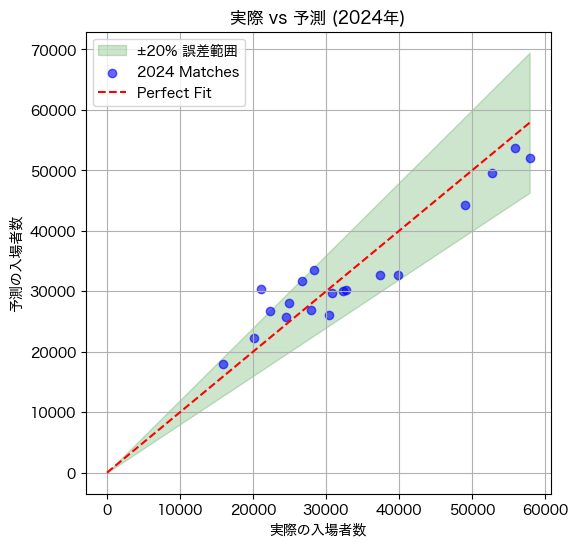

,対戦相手,スタジアム,実測値,予測値,誤差
155,広島,味スタ,32274,30118.577624,-2155.422376
156,神戸,味スタ,24974,28009.549056,3035.549056
157,浦和,国立,49005,44306.104613,-4698.895387
158,鹿島,国立,52772,49623.075475,-3148.924525
159,町田,味スタ,30811,29783.048677,-1027.951323
160,京都,味スタ,26770,31760.534486,4990.534486
161,柏,味スタ,22325,26666.457041,4341.457041
162,横浜FM,味スタ,30411,26162.037414,-4248.962586
163,Ｇ大阪,味スタ,27972,26895.619364,-1076.380636
164,磐田,味スタ,24580,25827.435393,1247.435393


In [25]:
import matplotlib.pyplot as plt
# フォント設定
plt.rcParams['font.family'] = 'Hiragino Sans'  

# ---------------------------------------------------------
# 5. 答え合わせ（可視化）
# ---------------------------------------------------------
# 精度スコアの計算
r2_test = r2_score(y_test, y_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))

print("========================================")
print(f"★ 2024年予測の精度 (R2): {r2_test:.3f}")
print(f"★ 誤差の大きさ (RMSE)  : {rmse_test:,.0f} 人")
print("========================================")

# 散布図で確認
plt.figure(figsize=(6, 6))

# 誤差±20%のエリアを描画
max_val = max(y_test.max(), y_pred.max())
x_line = np.linspace(0, max_val, 100)
plt.fill_between(x_line, x_line * 0.8, x_line * 1.2, 
                 alpha=0.2, color="green", label="±20% 誤差範囲")

plt.scatter(y_test, y_pred, color="blue", alpha=0.6, label="2024 Matches")

# 真ん中の線（ピッタリ賞のライン）
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="Perfect Fit")

plt.title("実際 vs 予測 (2024年)")
plt.xlabel("実際の入場者数")
plt.ylabel("予測の入場者数")
plt.legend()
plt.grid(True)
plt.show()

# 具体的にどの試合をどう外したか見る
results_df = pd.DataFrame({
    "対戦相手": df.loc[X_test.index, "アウェイ"],
    "スタジアム": df.loc[X_test.index, "スタジアム"],
    "実測値": y_test,
    "予測値": y_pred,
    "誤差": y_pred - y_test
})
display(results_df)